## Importing Libraries:

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import yfinance as yf
import datetime as dt
from datetime import timedelta , date
import plotly.graph_objects as go
import plotly.express as px
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX

## Getting today's date:

In [2]:
today = date.today()

## Defining our date range:

In [3]:
d1 = today.strftime("%Y-%m-%d")
end_date = d1
d2 = date.today() - timedelta(days=365)
d2 = d2.strftime("%Y-%m-%d")
start_date = d2
print("Your data will be between these dates: ", start_date, end_date)

Your data will be between these dates:  2025-09-13 2026-09-13


## Selecting the stock:

In [4]:
ticker = 'GOOGL'
df = yf.download(ticker,
                 start = start_date,
                 end = end_date,
                 progress=False)

## First Five Rows:

In [5]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,GOOGL,GOOGL,GOOGL,GOOGL,GOOGL
Date,,,,,
2025-09-15,250.957336,251.755264,244.025367,244.025367,58383800
2025-09-16,250.508514,252.383627,248.822896,251.426126,34109700
2025-09-17,248.882751,250.947389,245.641182,250.568370,34108000
2025-09-18,251.376266,253.331189,249.152055,251.027168,31239500
2025-09-19,254.059280,255.335959,251.156825,252.593092,55571400


## Information of Data:

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 250 entries, 2025-09-15 to 2026-09-11
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   (Close, GOOGL)   250 non-null    float64
 1   (High, GOOGL)    250 non-null    float64
 2   (Low, GOOGL)     250 non-null    float64
 3   (Open, GOOGL)    250 non-null    float64
 4   (Volume, GOOGL)  250 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 11.7 KB


## Date Index:

In [7]:
df.columns = df.columns.get_level_values(0)
df.insert(0,"Date",df.index,True)

## Converting date into actual column:

In [8]:
df.reset_index(drop=True, inplace=True)

## Looking at column names:

In [9]:
df.columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')

## Creating a Plot:

In [10]:
fig = px.line(
    df,
    x='Date',
    y='Close',
    title='Google Stock Price'
)
fig.show()

## Statistical info:

In [11]:
df.describe()

Price,Date,Close,High,Low,Open,Volume
count,250,250.000000,250.000000,250.000000,250.000000,2.500000e+02
mean,2026-03-13 23:08:09.600000,321.445652,325.181590,317.146907,321.103935,3.244166e+07
min,2025-09-15 00:00:00,235.956360,242.658931,235.228242,239.586941,1.009740e+07
25%,2025-12-11 06:00:00,300.828705,304.083463,295.789584,301.136716,2.457708e+07
50%,2026-03-14 12:00:00,321.804001,327.078757,316.971101,320.635277,2.947735e+07
75%,2026-06-11 18:00:00,346.689651,351.304205,342.130085,346.643530,3.566382e+07
max,2026-09-11 00:00:00,402.121185,408.103767,395.868935,399.424550,1.147063e+08
std,NaN,39.995191,40.496238,39.333393,39.888607,1.362959e+07


## Selecting only Date and Close:

In [12]:
df = df[['Date', 'Close']]

## ADF test:

In [13]:
def adf_test(df):
    result = adfuller(df)

    print('ADF Statistic: %f' % result[0])
    print('p-value: %f' % result[1])

    if result[1] <= 0.05:
        print("Reject the null hypothesis. Data is stationary")
    else:
        print("Fail to reject the null hypothesis. Data is not stationary")
adf_test(df['Close'])

ADF Statistic: -1.858562
p-value: 0.351799
Fail to reject the null hypothesis. Data is not stationary


## Differencing:

#### First Difference:

In [14]:
df['Close'].diff()

0           NaN
1     -0.448822
2     -1.625763
3      2.493515
4      2.683014
         ...   
245   -3.800018
246   -0.100006
247   -7.709991
248    1.950012
249    5.899994
Name: Close, Length: 250, dtype: float64

## Checking Stationarity now:

In [15]:
diff1 = df["Close"].diff().dropna()
adf_test(diff1)

ADF Statistic: -6.941899
p-value: 0.000000
Reject the null hypothesis. Data is stationary


## ARIMA model:

### Model choice
The ARIMA order `(2, 1, 2)` is used here as a baseline model for this analysis.

In [16]:
from statsmodels.tsa.arima.model import ARIMA
p, d, q = 2, 1, 2
model_Ar = ARIMA(
    df["Close"],
    order=(p,d,q)
)

## Train the model:

In [17]:
model_Ar = model_Ar.fit()

## Forecasting:

In [27]:
train = df["Close"][:-30]
test = df["Close"][-30:]

model = ARIMA(train, order=(2, 1, 2))
model_fit = model.fit()

forecast = model_Ar.forecast(steps=30)

c:\Users\RGB LAPTOPS\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\RGB LAPTOPS\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


## Evaluate:

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 9.029939013880938
RMSE: 13.12235816600093


## Plot of Actual vs Predicted:

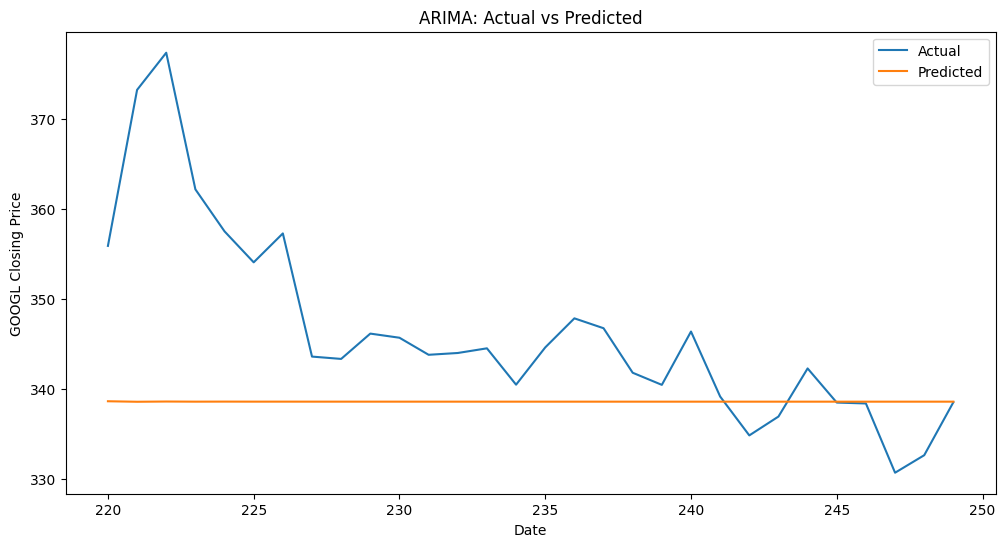

In [31]:
plt.figure(figsize=(12, 6))

plt.plot(test.index, test, label="Actual")
plt.plot(test.index, forecast, label="Predicted")

plt.title("ARIMA: Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("GOOGL Closing Price")
plt.legend()
plt.show()

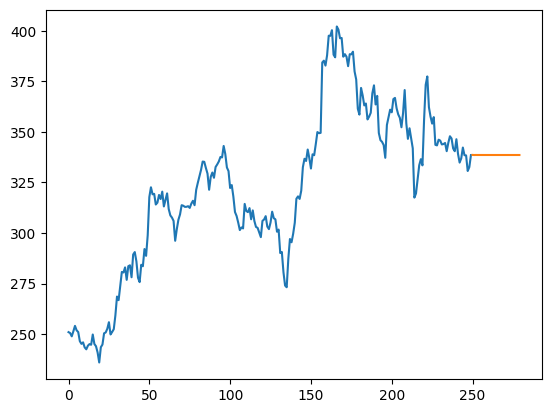

In [19]:
plt.plot(df['Close'], label='Actual')
plt.plot(forecast, label='Forecast')

# ACF & PACF:

>ACF :Correlation with previous observations

>PACF : Correlation after removing intermediate lags

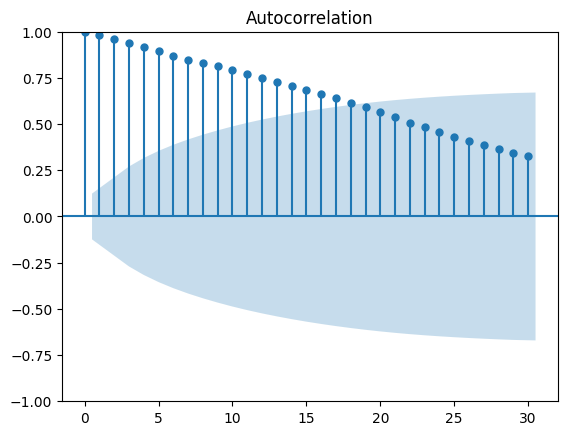

In [20]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt
plot_acf(df["Close"], lags=30)
plt.show()

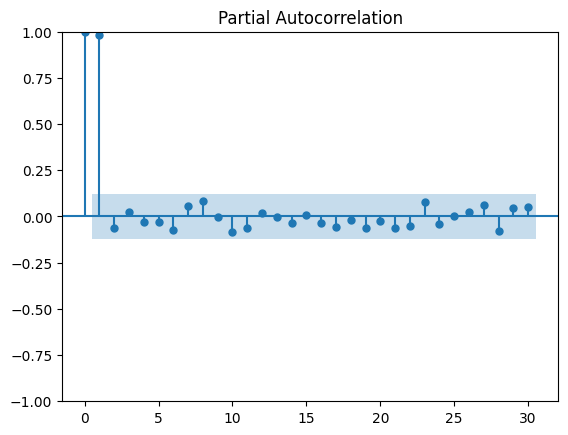

In [21]:
plot_pacf(df["Close"], lags=30)
plt.show()

***********

# SARIMA:

**Note:** The seasonal period used below is kept from the original analysis. For daily stock prices, this should be treated as an exploratory SARIMA setup rather than proof of a real seasonal pattern.

In [22]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
model_SR = SARIMAX(
    df['Close'],
    order=(p, d, q),
    seasonal_order=(p, d, q, 12)
)

In [23]:
model_SR = model_SR.fit()

c:\Users\RGB LAPTOPS\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [24]:
predictions = model_SR.predict(
    start=len(df['Close']),
    end=len(df['Close'])+10
)

## Hypertuning:

> we are using pmdarima

In [25]:
from pmdarima import auto_arima

In [26]:
model = auto_arima(
    df["Close"],
    seasonal=True,
    m=12,
    trace=True,
    suppress_warnings=True
)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=1650.094, Time=0.96 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=1641.228, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=1643.417, Time=0.21 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=1643.192, Time=0.23 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=1639.960, Time=0.02 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : AIC=1642.975, Time=0.12 sec
 ARIMA(0,1,0)(0,0,1)[12] intercept   : AIC=1642.970, Time=0.12 sec
 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=1644.961, Time=0.15 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=1641.663, Time=0.04 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : AIC=1641.433, Time=0.05 sec
 ARIMA(1,1,1)(0,0,0)[12] intercept   : AIC=1642.415, Time=0.09 sec

Best model:  ARIMA(0,1,0)(0,0,0)[12]          
Total fit time: 2.059 seconds


## Final note
This notebook demonstrates ARIMA/SARIMA forecasting on GOOGL closing prices. The models and parameters are exploratory, and stock prices are difficult to predict reliably.

Conclusion: The original GOOGL closing-price series was non-stationary, while first differencing produced a stationary series. An ARIMA(2,1,2) model was then fitted and evaluated using MAE and RMSE on a held-out test set.